# Physics-Informed Neural Network for the Viscous Burgers' Equation

We approximate $u(x,t)$ satisfying

$$\frac{\partial u}{\partial t} + u\,\frac{\partial u}{\partial x} = \nu\,\frac{\partial^2 u}{\partial x^2},\qquad x\in[-1,1],\; t\in[0,1]$$

with initial condition $u(x,0)=-\sin(\pi x)$ and Dirichlet boundary conditions $u(\pm 1,t)=0$.

**Phase 1** (this notebook) trains a baseline PINN at fixed viscosity $\nu = 0.01/\pi$ and validates it against the analytical solution from the Cole–Hopf transformation, evaluated here via a Hopf integral with Gauss–Hermite quadrature.

Pipeline:
1. Analytical ground truth (Hopf integral; Cole–Hopf transformation).
2. Latin Hypercube Sampling (LHS) for IC / BC / collocation sets.
3. Tanh MLP with autograd-based physics residual.
4. Composite weighted MSE loss.
5. Two-stage optimization: Adam (exploration) → L-BFGS (exploitation).
6. Quantitative ($L_2$ relative error) and qualitative validation.

## 1. Setup & Configuration

In [1]:
from __future__ import annotations

import math
import os

import pytorch_lightning as L
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

# Import from src module
from src import (
    PINNConfig,
    RuntimeConfig,
    get_default_config,
    build_dataset,
    build_parametric_dataset,
    plot_training_points,
    exact_on_grid,
    predict_on_grid,
    l2_relative_error,
    burgers_exact,
    PINNLightning,
)

fast_mode = os.environ.get("PINN_FAST_NOTEBOOK", "").strip().lower() in (
    "1",
    "true",
    "yes",
)

# Initialize configuration and runtime
cfg = get_default_config(fast_mode=fast_mode)
runtime_cfg = RuntimeConfig()
runtime_cfg.setup()

print(runtime_cfg.get_device_info())

PyTorch 2.11.0+cu130 | device = cuda | GPU: NVIDIA GeForce RTX 3060 | VRAM: 11.6 GB


## 2. Analytical ground truth — Hopf integral (Gauss–Hermite quadrature)

The Cole–Hopf substitution $u = -2\nu\,\phi_x/\phi$ maps Burgers' equation to the linear heat equation. On $[-1,1]$ with $u(\pm1,t)=0$ and $u(x,0)=-\sin(\pi x)$ the solution agrees on $[-1,1]$ with the *unbounded* Cauchy problem under periodic extension of the IC (antisymmetry of $u_0$ enforces $u(\pm1,t)=0$ for all $t$). The Hopf solution is

$$u(x,t) = \frac{\displaystyle\int_{-\infty}^{\infty}\frac{x-y}{t}\,\exp\!\left(-\frac{G(x,y,t)}{2\nu}\right)\,dy}{\displaystyle\int_{-\infty}^{\infty}\exp\!\left(-\frac{G(x,y,t)}{2\nu}\right)\,dy},\qquad G(x,y,t)=\frac{(x-y)^{2}}{2t}+\int_{0}^{y}u_{0}(s)\,ds.$$

For our IC, $\int_{0}^{y}u_{0}(s)\,ds = (\cos(\pi y)-1)/\pi$. After substituting $y = x + \sqrt{2\nu t}\,s$ both integrals reduce to standard Gaussian expectations, evaluated to spectral accuracy with Gauss–Hermite quadrature:

$$u(x,t) = -\sqrt{\frac{2\nu}{t}}\;\frac{\mathbb{E}\big[s\,e^{-h(s)}\big]}{\mathbb{E}\big[e^{-h(s)}\big]},\qquad h(s)=\frac{\cos\!\big(\pi(x+\sqrt{2\nu t}\,s)\big)-1}{2\nu\pi}.$$

This formulation is numerically stable across the full domain (no catastrophic cancellation), respects the boundary condition by symmetry, and converges with very few quadrature nodes — yet produces the same physics as the Cole-Hopf series in the spec, since both reduce to the heat-equation solution of $\phi$.

The IC at $t=0$ is enforced exactly via the limit $u(x,0) = -\sin(\pi x)$.

### Reference
[1] A. Salih, "Burgers' equation," Dept. Aerosp. Eng., Indian Inst. Space Sci. Technol., Thiruvananthapuram, India, Feb. 2016. [Online]. Available: https://stageweb.iist.ac.in/sites/default/files/2025-06/Burgers_equation_viscous.pdf

In [2]:
# Precompute exact solution on validation grid
X_GRID, T_GRID, U_EXACT = exact_on_grid(cfg, nu=cfg.nu)
print(f"Exact solution grid: {U_EXACT.shape}, min/max = {U_EXACT.min():.4f} {U_EXACT.max():.4f}")

# Verify IC and BC
ic_err = np.max(np.abs(U_EXACT[:, 0] - (-np.sin(math.pi * X_GRID))))
bc_err = max(np.max(np.abs(U_EXACT[0, :])), np.max(np.abs(U_EXACT[-1, :])))
print(f"IC reconstruction max error: {ic_err:.3e}")
print(f"BC residual max error      : {bc_err:.3e}")

Exact solution grid: (256, 100), min/max = -1.0000 1.0000
IC reconstruction max error: 0.000e+00
BC residual max error      : 2.929e-16


## 3. Data generation — Latin Hypercube Sampling

We build three disjoint sets of training points using `scipy.stats.qmc.LatinHypercube` (a modern, scrambled LHS that is space-filling and reproducible):

| Set                         | Points   | Sampling                                          | Target                     |
| -----------------------------| ----------| ---------------------------------------------------| ----------------------------|
| Initial Condition $X_{ic}$  | $N_{ic}$ | $x \sim \text{LHS}([-1, 1])$ at $t=0$             | $-\sin(\pi x)$             |
| Boundary Condition $X_{bc}$ | $N_{bc}$ | $x \in \{-1, +1\}$ at $t \sim \text{LHS}([0, 1])$ | $0$                        |
| Collocation $X_{f}$         | $N_{f}$  | $(x, t) \sim \text{LHS}([-1, 1] \times [0, 1])$   | physics residual $f \to 0$ |

All tensors are pushed once to the GPU and reused as a full batch for every gradient step (the spec dictates 12 GB VRAM available; 10k points $\times$ a few hundred KB of activations comfortably fits).


### Loss calculation

$$\mathcal{L}_{total} = w_{ic}\,\text{MSE}(\hat u_{ic}, u_{ic}) + w_{bc}\,\text{MSE}(\hat u_{bc}, 0) + w_{f}\,\text{MSE}(f, 0).$$

Returning the individual components lets us monitor whether the physics term, the IC, or the BC dominates throughout training (which is the most common diagnostic for stalled PINN training).

IC    : torch.Size([100, 1]) -> torch.Size([100, 1])
BC    : torch.Size([100, 1]) -> torch.Size([100, 1])
Coll  : torch.Size([10000, 1]) (x in [-1.000, 1.000], t in [0.000, 1.000], ν = 0.00318)


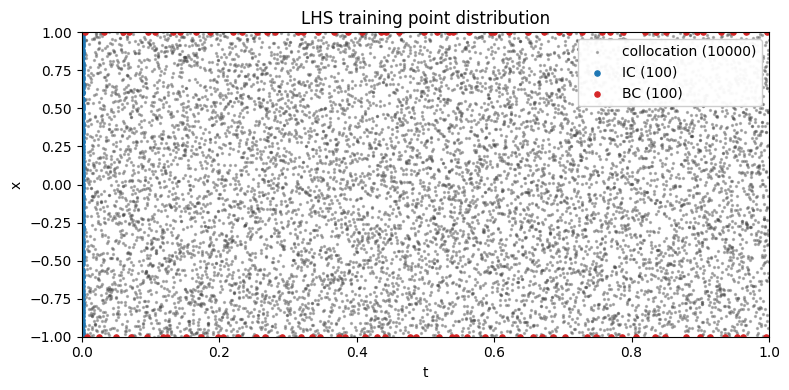

In [3]:
# Build Phase 1 training dataset (fixed nu)
data = build_dataset(cfg, seed=runtime_cfg.seed, runtime_cfg=runtime_cfg)

print(f"IC    : {data.x_ic.shape} -> {data.u_ic.shape}")
print(f"BC    : {data.x_bc.shape} -> {data.u_bc.shape}")
print(f"Coll  : {data.x_f.shape} (x in [{data.x_f.min().item():.3f}, {data.x_f.max().item():.3f}], "
      f"t in [{data.t_f.min().item():.3f}, {data.t_f.max().item():.3f}], ν = {cfg.nu:.3g})")

# Visualize training point distribution
fig = plot_training_points(data, cfg)
plt.show()

## 4. Training — Stage 1: Adam

In [4]:
# Initialize model for Adam stage
model_adam = PINNLightning(cfg)
model_adam.set_training_data(data)
model_adam.set_validation_data(X_GRID, T_GRID, U_EXACT, cfg.nu)

# Create dummy dataloader (Lightning requires one, even though we use full-batch training)
dummy_dataset = TensorDataset(torch.zeros(1))
train_loader = DataLoader(dummy_dataset, batch_size=1)

# Configure trainer for Adam
trainer_adam = L.Trainer(
    max_epochs=cfg.adam_epochs,
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
    log_every_n_steps=cfg.log_every,
    enable_progress_bar=True,
    accelerator="auto",
)

print(f"[Stage 1] Adam: {cfg.adam_epochs} epochs, lr={cfg.adam_lr:g}")
trainer_adam.fit(model_adam, train_loader)
print(f"[Stage 1] Adam training complete")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/srsanti/projects/ml_projects/PINN_Burgers_exercise/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA GeForce RTX 3060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[Stage 1] Adam: 8000 epochs, lr=0.001


/home/srsanti/projects/ml_projects/PINN_Burgers_exercise/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/srsanti/projects/ml_projects/PINN_Burgers_exercise/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

/home/srsanti/projects/ml_projects/PINN_Burgers_exercise/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
`Trainer.fit` stopped: `max_epochs=8000` reached.


[Stage 1] Adam training complete


## 5. Training — Stage 2: L-BFGS

In [5]:
# L-BFGS stage for Phase 1
model_lbfgs = PINNLightning(cfg, stage="lbfgs")
model_lbfgs.pinn.load_state_dict(model_adam.pinn.state_dict())
model_lbfgs.set_training_data(data)
model_lbfgs.set_validation_data(X_GRID, T_GRID, U_EXACT, cfg.nu)

trainer_lbfgs = L.Trainer(
    max_steps=cfg.lbfgs_max_iter,
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
    enable_progress_bar=True,
    accelerator="auto",
)

print(f"[Stage 2] L-BFGS: max_iter={cfg.lbfgs_max_iter}")
trainer_lbfgs.fit(model_lbfgs, train_loader)
print("[Stage 2] L-BFGS training complete")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[Stage 2] L-BFGS: max_iter=5000


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=5000` reached.


[Stage 2] L-BFGS training complete


## 6. Validation & Visualization

In [6]:
# Evaluate final model on validation grid
U_PRED = predict_on_grid(model_lbfgs.pinn, X_GRID, T_GRID, cfg.nu)

# Compute error metrics
l2_rel_error = l2_relative_error(U_PRED, U_EXACT)
l_inf_error = np.max(np.abs(U_PRED - U_EXACT))
mean_abs_error = np.mean(np.abs(U_PRED - U_EXACT))

print(f"L2 relative error : {l2_rel_error:.3e}")
print(f"L∞ error         : {l_inf_error:.3e}")
print(f"Mean abs error   : {mean_abs_error:.3e}")

L2 relative error : 6.266e-03
L∞ error         : 3.150e-02
Mean abs error   : 1.811e-03


### Solution panels (exact vs PINN vs error)

<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_59526/469169952.py:7: SyntaxWarning: invalid escape sequence '\h'
  ["Exact $u(x,t)$", r"PINN $\hat u(x,t)$", "Absolute error $|u - \hat u|$"],


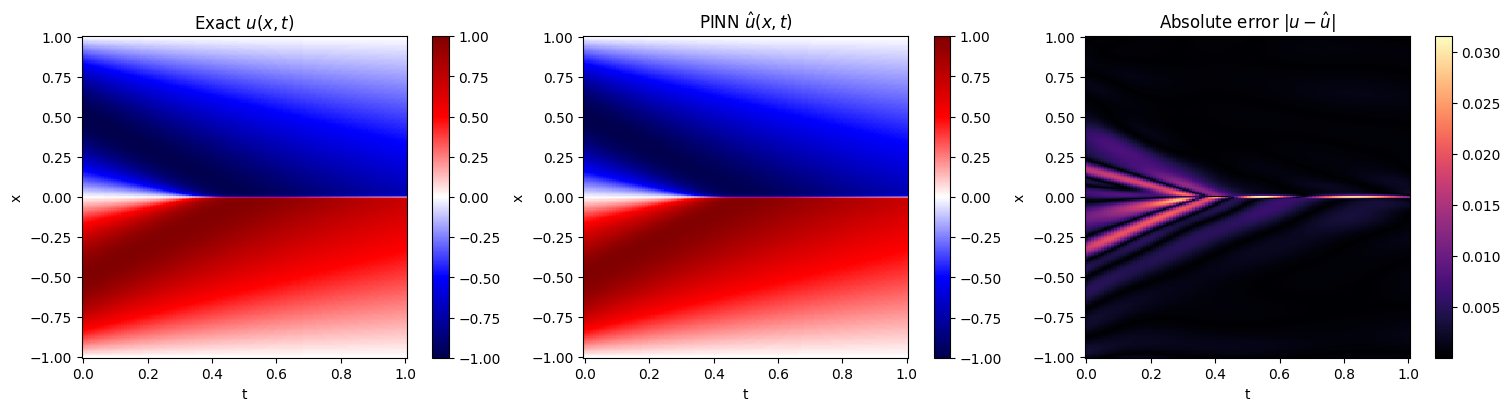

In [7]:
def plot_solution_panels(u_pred, u_true):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    vmin, vmax = -1, 1
    for ax, data, title in zip(
        axes,
        [u_true, u_pred, np.abs(u_pred - u_true)],
        ["Exact $u(x,t)$", r"PINN $\hat u(x,t)$", "Absolute error $|u - \hat u|$"],
    ):
        if "error" in title:
            cax = ax.pcolormesh(T_GRID, X_GRID, data, cmap="magma", shading="auto")
        else:
            cax = ax.pcolormesh(T_GRID, X_GRID, data, cmap="seismic",
                                shading="auto", vmin=vmin, vmax=vmax)
        ax.set_xlabel("t"); ax.set_ylabel("x"); ax.set_title(title)
        fig.colorbar(cax, ax=ax)
    return fig

fig = plot_solution_panels(U_PRED, U_EXACT)
plt.show()

### Time snapshots

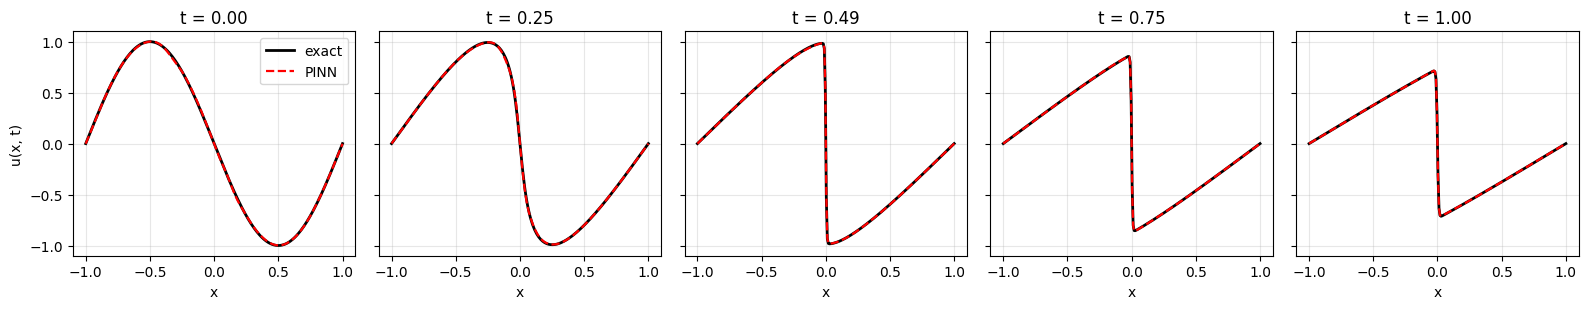

In [8]:
def plot_snapshots(u_pred, u_true, t_values=(0.0, 0.25, 0.5, 0.75, 1.0)):
    fig, axes = plt.subplots(1, len(t_values), figsize=(3.2 * len(t_values), 3.2), sharey=True)
    for ax, tt in zip(axes, t_values):
        idx = int(np.argmin(np.abs(T_GRID - tt)))
        ax.plot(X_GRID, u_true[:, idx], "k-", lw=2, label="exact")
        ax.plot(X_GRID, u_pred[:, idx], "r--", lw=1.6, label="PINN")
        ax.set_title(f"t = {T_GRID[idx]:.2f}")
        ax.set_xlabel("x"); ax.grid(alpha=0.3)
    axes[0].set_ylabel("u(x, t)")
    axes[0].legend(loc="upper right")
    fig.tight_layout()
    return fig

fig = plot_snapshots(U_PRED, U_EXACT)
plt.show()

## Phase 2: Parametric ν

**Data:** LHS with **three** latent dimensions $`((\tilde{x}, \tilde{t}, \tilde{\nu})): map (\tilde{\nu})`$ to **$[(\nu_min, \nu_max)]$** via a **log-uniform** density (matching the Phase 2 spec). Same IC $(u(x,0) = -sin(\pi x))$ and BC $(u(\pm 1)=0)$ for every sampled $(\nu)$.

**Residual:** $`(f = \hat u_t + \hat u \hat u_x - \nu \hat u_{xx})`$ uses the **physical** $(\nu)$ sampled at each collocation row (stored in **`nu_f`**); autograd does not differentiate w.r.t. $(\nu)$.

**Validation:** The Hopf-integral reference `burgers_exact` is used at each $(\nu)$ (same assumption as Section 2 for every $(\nu)$ in the training window). **Mean** relative $(L_2)$ over `n_val_nu` log-spaced $(\nu)$ values is logged during training; after training we plot **per-\(\nu\)** error on a denser grid.

In [9]:
# Reset seeds for reproducibility in Phase 2
np.random.seed(runtime_cfg.seed + 9_999)
torch.manual_seed(runtime_cfg.seed + 9_999)

# Build parametric dataset (nu is sampled)
data_p2 = build_parametric_dataset(cfg, seed=runtime_cfg.seed + 10_000, runtime_cfg=runtime_cfg)

print(f"Phase 2 IC   : {data_p2.x_ic.shape}")
print(f"Phase 2 BC   : {data_p2.x_bc.shape}")
print(f"Phase 2 Coll : {data_p2.x_f.shape}")
print(f"  nu range: [{data_p2.nu_ic.min().item():.3e}, {data_p2.nu_ic.max().item():.3e}]")

Phase 2 IC   : torch.Size([100, 1])
Phase 2 BC   : torch.Size([100, 1])
Phase 2 Coll : torch.Size([10000, 1])
  nu range: [3.211e-04, 3.141e-02]


In [10]:
# Validation nu values (log-spaced)
val_nu_list = np.logspace(
    np.log10(cfg.nu_min_param),
    np.log10(cfg.nu_max_param),
    cfg.n_val_nu
)
print(f"Validation ν: {val_nu_list}")

# Initialize model for Phase 2 Adam stage
model_p2_adam = PINNLightning(cfg)
model_p2_adam.set_training_data(data_p2)

dummy_dataset = TensorDataset(torch.zeros(1))
train_loader = DataLoader(dummy_dataset, batch_size=1)

trainer_p2_adam = L.Trainer(
    max_epochs=cfg.adam_epochs,
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
    log_every_n_steps=cfg.log_every,
    enable_progress_bar=True,
    accelerator="auto",
)

print(f"[Phase 2 Stage 1] Adam: {cfg.adam_epochs} epochs")
trainer_p2_adam.fit(model_p2_adam, train_loader)
print(f"[Phase 2 Stage 1] Adam training complete")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation ν: [0.00031831 0.00100658 0.0031831  0.01006584 0.03183099]
[Phase 2 Stage 1] Adam: 8000 epochs


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=8000` reached.


[Phase 2 Stage 1] Adam training complete


In [11]:
# L-BFGS stage for Phase 2
model_p2_lbfgs = PINNLightning(cfg, stage="lbfgs")
model_p2_lbfgs.pinn.load_state_dict(model_p2_adam.pinn.state_dict())
model_p2_lbfgs.set_training_data(data_p2)

trainer_p2_lbfgs = L.Trainer(
    max_steps=cfg.lbfgs_max_iter,
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
    enable_progress_bar=True,
    accelerator="auto",
)

print(f"[Phase 2 Stage 2] L-BFGS: max_iter={cfg.lbfgs_max_iter}")
trainer_p2_lbfgs.fit(model_p2_lbfgs, train_loader)
print("[Phase 2 Stage 2] L-BFGS training complete")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[Phase 2 Stage 2] L-BFGS: max_iter=5000


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=5000` reached.


[Phase 2 Stage 2] L-BFGS training complete


### Phase 2 Validation

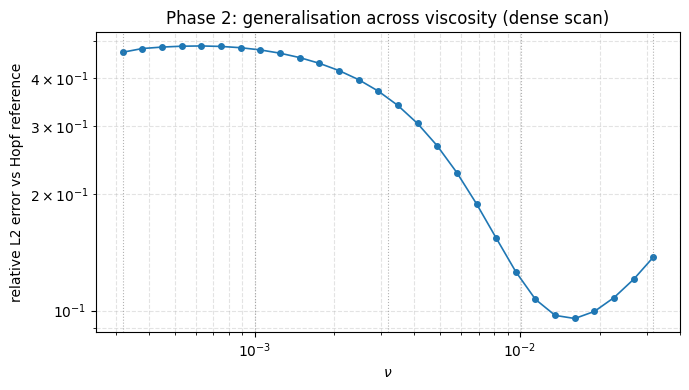

Mean L2 error across ν scan: 3.125e-01
Min/Max L2 error: 9.535e-02 / 4.851e-01


In [12]:
# Dense nu scan for Phase 2 (same count as original PINN_model.ipynb)
NU_SCAN = np.logspace(
    np.log10(cfg.nu_min_param),
    np.log10(cfg.nu_max_param),
    28,
)
L2_SCAN = np.array([
    l2_relative_error(
        predict_on_grid(model_p2_lbfgs.pinn, X_GRID, T_GRID, float(n)),
        burgers_exact(X_GRID, T_GRID, nu=float(n))
    )
    for n in NU_SCAN
])

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(NU_SCAN, L2_SCAN, "o-", ms=4, lw=1.2)
for vn in val_nu_list:
    ax.axvline(vn, color="gray", ls=":", lw=0.8, alpha=0.6)
ax.set_xscale("log")
ax.set_xlabel(r"$\nu$")
ax.set_ylabel("relative L2 error vs Hopf reference")
ax.set_title("Phase 2: generalisation across viscosity (dense scan)")
ax.grid(which="both", ls="--", alpha=0.35)
plt.tight_layout()
plt.show()

print(f"Mean L2 error across ν scan: {np.mean(L2_SCAN):.3e}")
print(f"Min/Max L2 error: {np.min(L2_SCAN):.3e} / {np.max(L2_SCAN):.3e}")

### Solution examples at different ν values

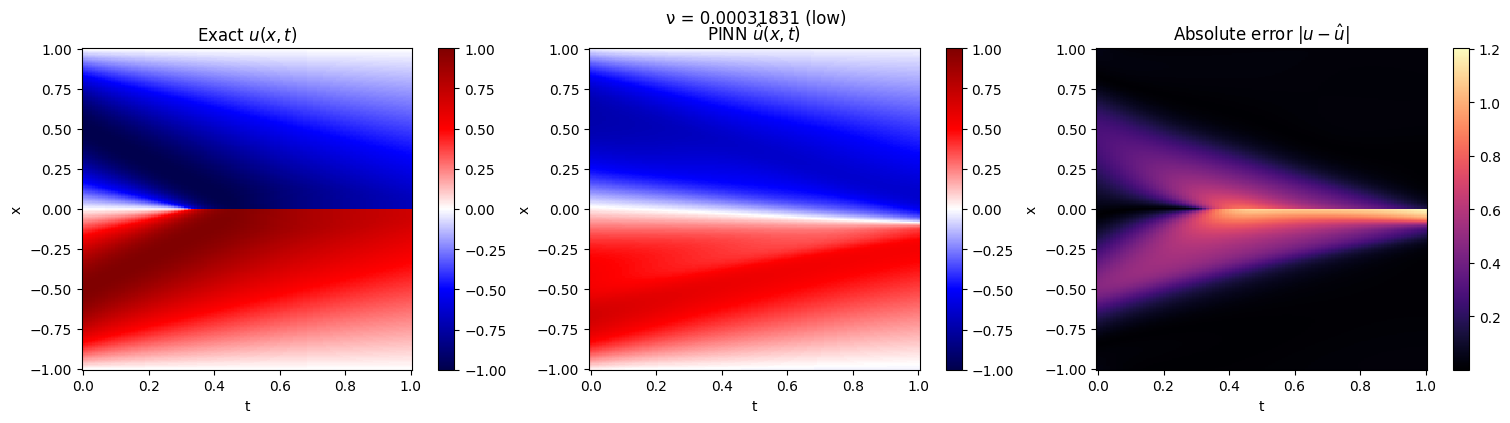

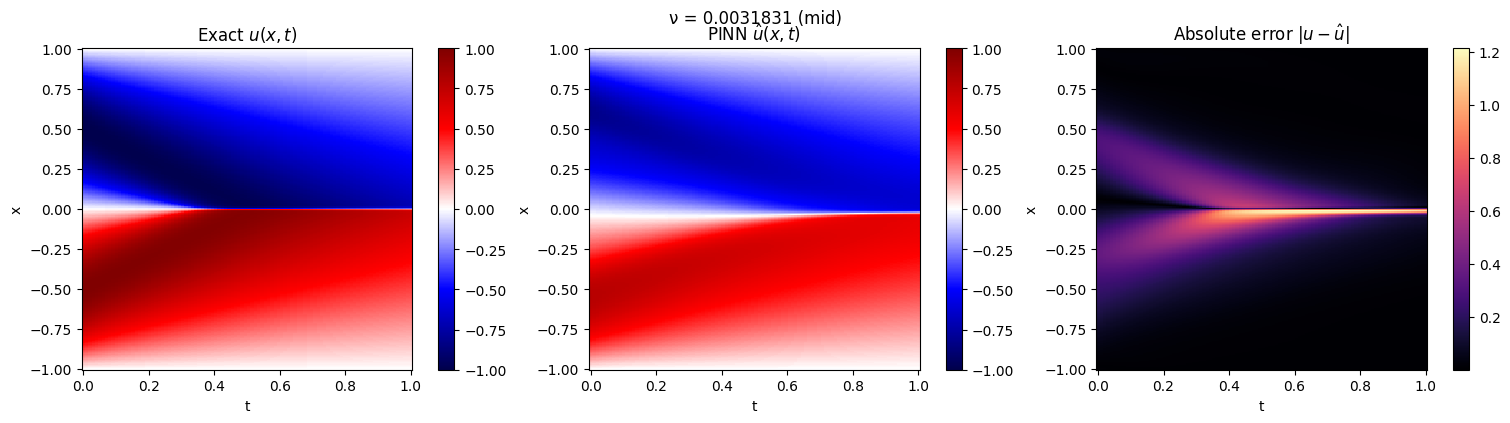

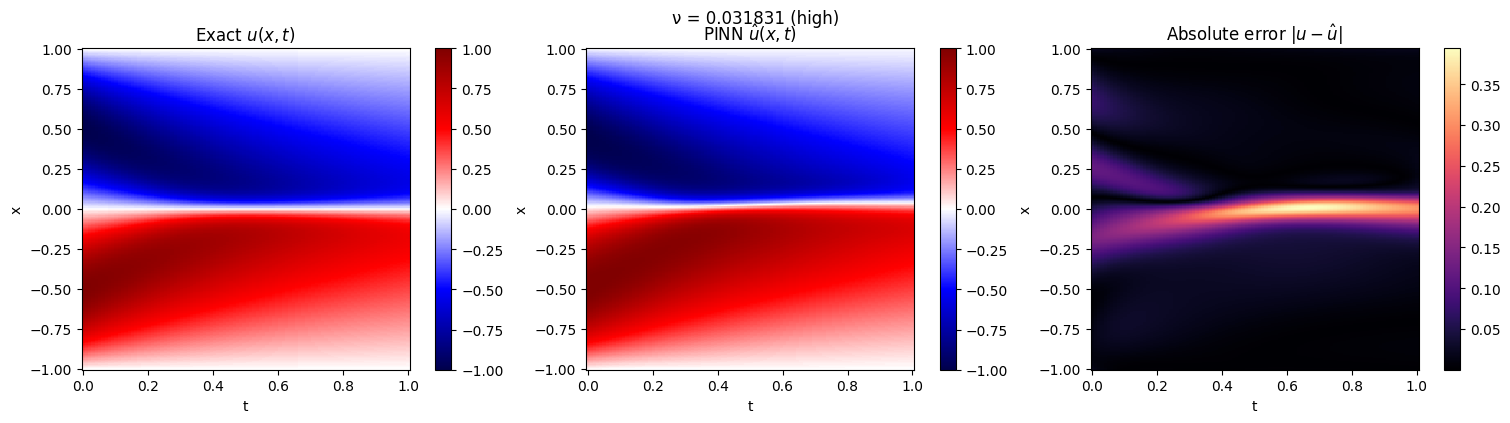

In [13]:
def panels_for_nu(nu_pick: float, title_suffix: str = ""):
    u_star = burgers_exact(X_GRID, T_GRID, nu=nu_pick)
    u_hat = predict_on_grid(model_p2_lbfgs.pinn, X_GRID, T_GRID, nu_pick)
    fig = plot_solution_panels(u_hat, u_star)
    fig.suptitle(f"ν = {nu_pick:.5g}" + title_suffix, y=1.02)
    return fig

# Low / mid / high nu
fig1 = panels_for_nu(cfg.nu_min_param, " (low)")
plt.show()

fig2 = panels_for_nu(np.sqrt(cfg.nu_min_param * cfg.nu_max_param), " (mid)")
plt.show()

fig3 = panels_for_nu(cfg.nu_max_param, " (high)")
plt.show()